# **XPM Identity Operator Analysis**

This notebook loads trained parameters from a run directory and generates analysis plots.

In [123]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import json

# ML imports
import torch
import torch.nn.functional as F

# Import module
from nlse import *

## **Setup: Load Run Directory**

In [124]:
# Specify the run directory to analyze
# You can change this to point to any run directory
run_dir = Path("res/loss-fn-hg/")  # Change this to your run directory

print(f"Analyzing run directory: {run_dir}")

Analyzing run directory: res\loss-fn-hg


## **Load Configuration and Parameters**

In [125]:
# Load configuration
config_path = run_dir / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Load losses
losses_path = run_dir / "losses.json"
with open(losses_path, "r") as f:
    losses = json.load(f)

# Load theta parameters
theta_path = run_dir / "parameters" / "theta.npy"
theta = torch.from_numpy(np.load(theta_path)).float()

print(f"Loaded theta with shape: {theta.shape}")
print(f"Configuration loaded from: {config_path}")
print(f"Losses loaded from: {losses_path}")

Loaded theta with shape: torch.Size([500])
Configuration loaded from: res\loss-fn-hg\config.yaml
Losses loaded from: res\loss-fn-hg\losses.json


## **Device Configuration**

In [126]:
# Device configuration for GPU support
device_config = config.get("device", {})
use_cuda = device_config.get("use_cuda", True) and torch.cuda.is_available()
if use_cuda:
    device_id = device_config.get("device_id", 0)
    device = torch.device(f"cuda:{device_id}")
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(device_id)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(device_id).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# Move theta to device
theta = theta.to(device)

Using device: cpu


## **Reconstruct Simulation Setup**

In [127]:
# Extract parameters from config
sim = config["simulation"]
med = config["medium"]
pulse = config["pulse"]
train = config["training"]
plot = config["plotting"]

# Simulation parameters
Lz = float(sim["Lz"])
Nz = int(sim["Nz"])
Lt = float(sim["Lt"])
Nt = int(sim["Nt"])
N_modes = int(sim["N_modes"])

# Medium parameters
beta2_j = float(med["beta2_j"])
beta2_k = float(med["beta2_k"])
gamma_j = float(med["gamma_j"])
gamma_k = float(med["gamma_k"])

# Pulse parameters
tau = float(pulse["tau"])

# Training parameters
batch_size = int(train["batch_size"])
amplitude_downscale = float(train["amplitude_downscale"])

# Calculate derived parameters
dz = Lz / Nz
dt = Lt / Nt

# Create time grid
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32, device=device)

# Define HG basis
hg_basis = get_hg_basis(N_modes, t, tau)

# Get batch of pulses (same as training)
B = batch_size
x = get_hg_basis(B, t, tau) * amplitude_downscale  # inputs
y = x.clone().detach()  # labels

print(f"Simulation setup reconstructed:")
print(f"  Lz={Lz}, Nz={Nz}, dz={dz}")
print(f"  Lt={Lt}, Nt={Nt}, dt={dt}")
print(f"  Batch size: {B}")
print(f"  HG modes: {N_modes}")

Precomputed 500 HG basis functions on grid of 4096 points on device cpu
Precomputed 16 HG basis functions on grid of 4096 points on device cpu
Simulation setup reconstructed:
  Lz=0.001, Nz=200, dz=5e-06
  Lt=16.0, Nt=4096, dt=0.00390625
  Batch size: 16
  HG modes: 500


## **Forward Pass with Loaded Parameters**

In [128]:
# Define forward pass function (same as training)
def forward(theta, hg_basis):
    Ain_k = hg_to_time(theta, hg_basis)
    return split_step_fourier_xpm_batch(
        x, Ain_k, dz, Nz, 
        beta2_j, beta2_k, 
        gamma_j, gamma_k, 
        Lt
    )

# Run forward pass with loaded theta
print("Running forward pass with loaded theta...")
with torch.no_grad():
    A_j_evolution, A_k_evolution = forward(theta, hg_basis)

print(f"Forward pass completed!")
print(f"  A_j_evolution shape: {A_j_evolution.shape}")
print(f"  A_k_evolution shape: {A_k_evolution.shape}")

Running forward pass with loaded theta...
Forward pass completed!
  A_j_evolution shape: torch.Size([16, 4096, 201])
  A_k_evolution shape: torch.Size([16, 4096, 201])


## **Plotting Setup**

In [129]:
# Plotting parameters
plot_percent = plot.get("plot_percent", 0.2)
modes_to_plot = plot.get("modes_to_plot", [0, 4, 15])

# Calculate the indices for the central portion
total_points = len(t)
center_points = int(total_points * plot_percent)
start_idx = (total_points - center_points) // 2
end_idx = start_idx + center_points
t_center = t[start_idx:end_idx].cpu().numpy()

print(f"Plotting parameters:")
print(f"  Plot percent: {plot_percent}")
print(f"  Modes to plot: {modes_to_plot}")

Plotting parameters:
  Plot percent: 0.3
  Modes to plot: [0, 4, 15]


## **Analysis**


### 1. Training Loss

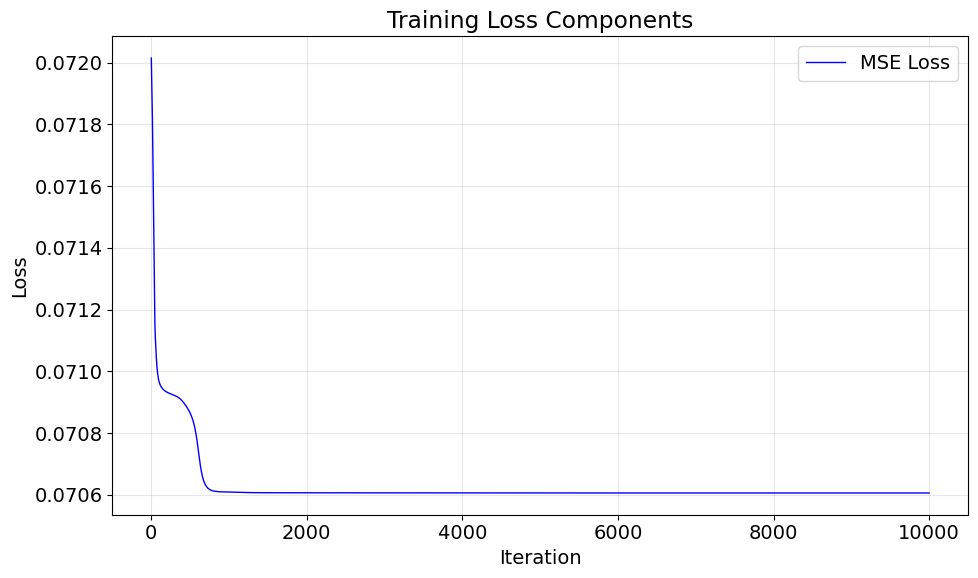

Final Loss: 0.070606
Final MSE Loss: 0.070606
Final Penalty Loss: 1.526849e-09


In [130]:
# Plot the loss
plt.figure(figsize=(10, 6))
#plt.plot(losses["losses"], color="m", label="Total Loss", linewidth=1)
plt.plot(losses["losses_mse"], color="b", label="MSE Loss", linewidth=1)
#plt.plot(losses["losses_pen"], color="r", label="Penalty Loss", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Loss: {losses['final_loss']:.6f}")
print(f"Final MSE Loss: {losses['final_loss_mse']:.6f}")
print(f"Final Penalty Loss: {losses['final_loss_pen']:.6e}")

### 2. Analzyzing specific mode

In [131]:
mode_nr = 15

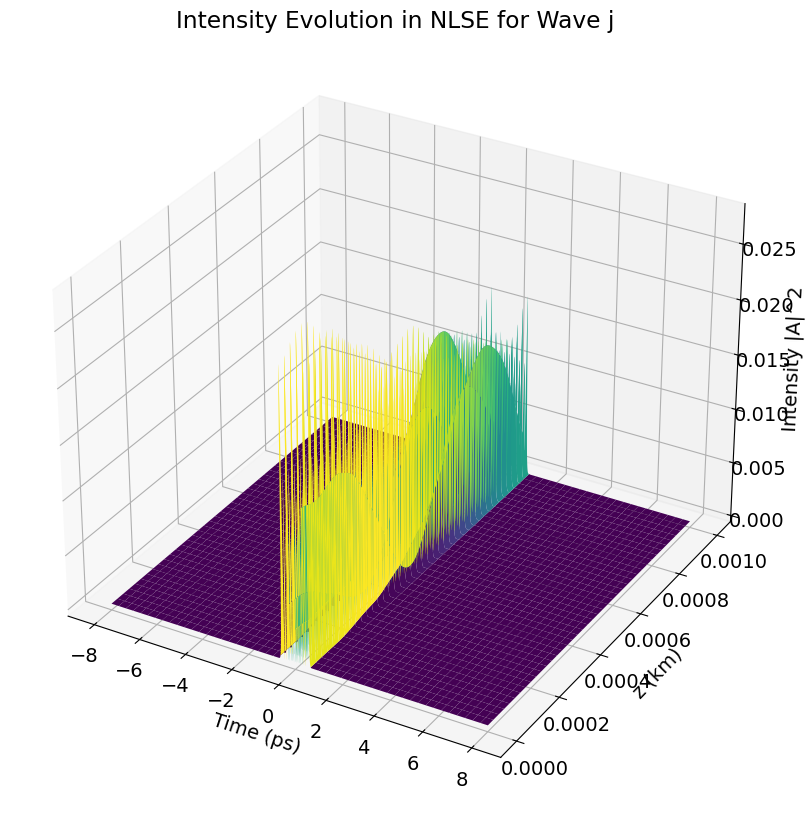

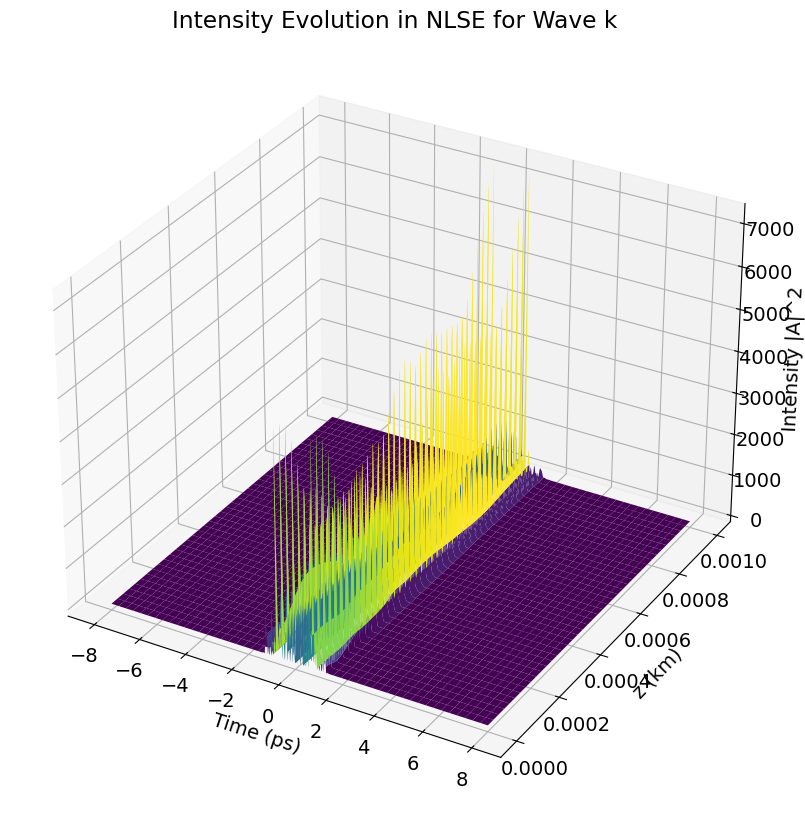

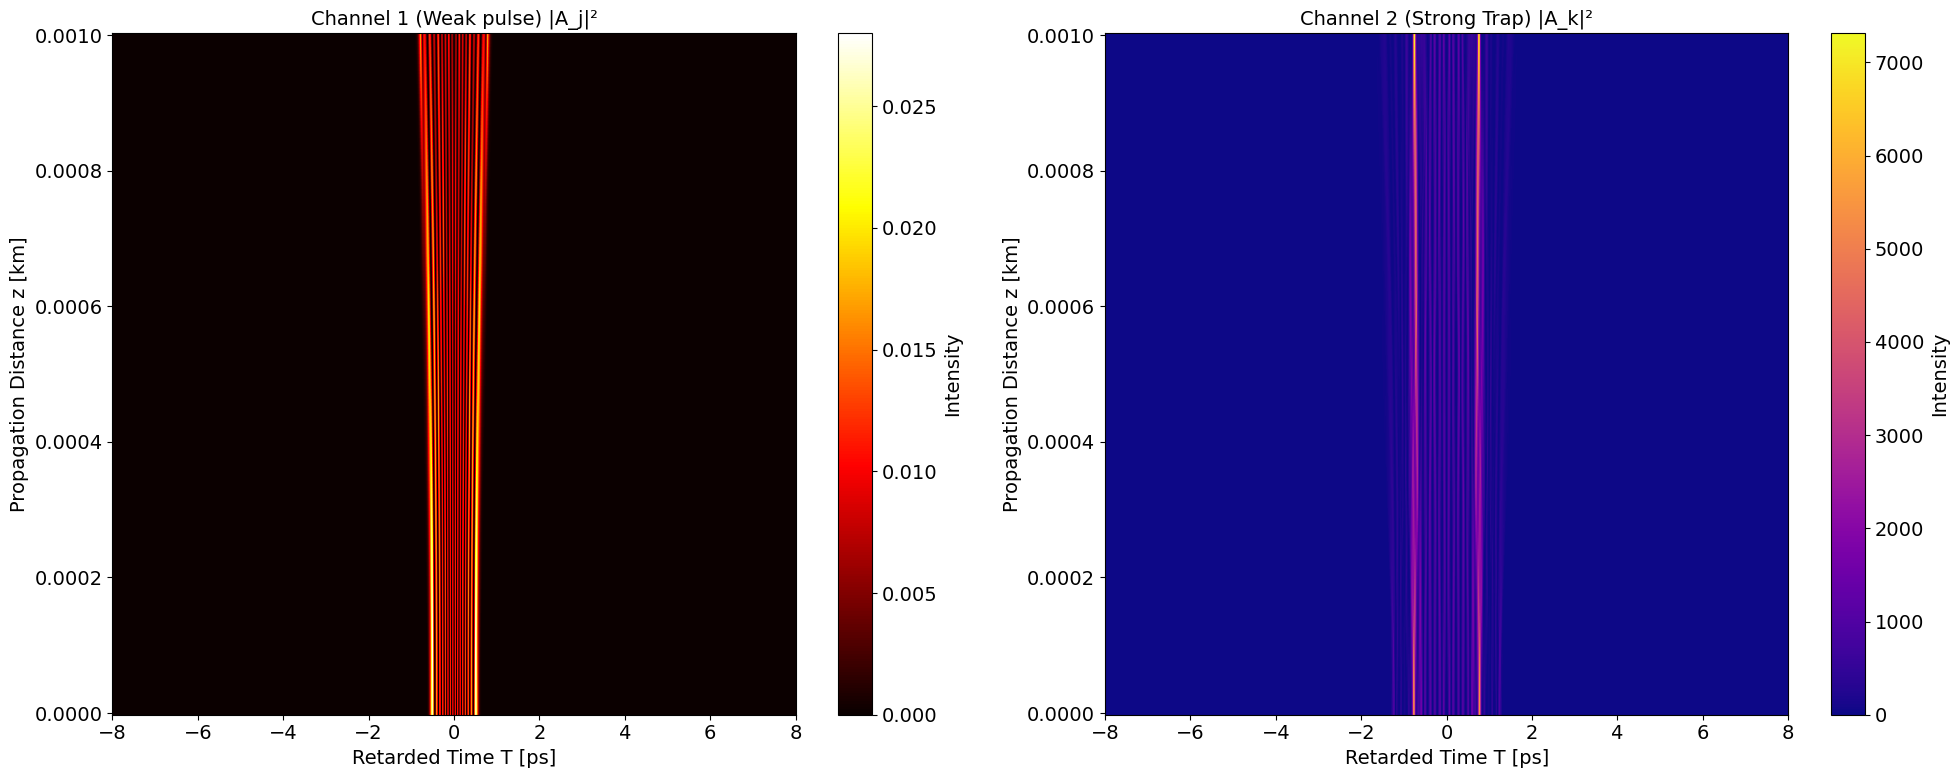

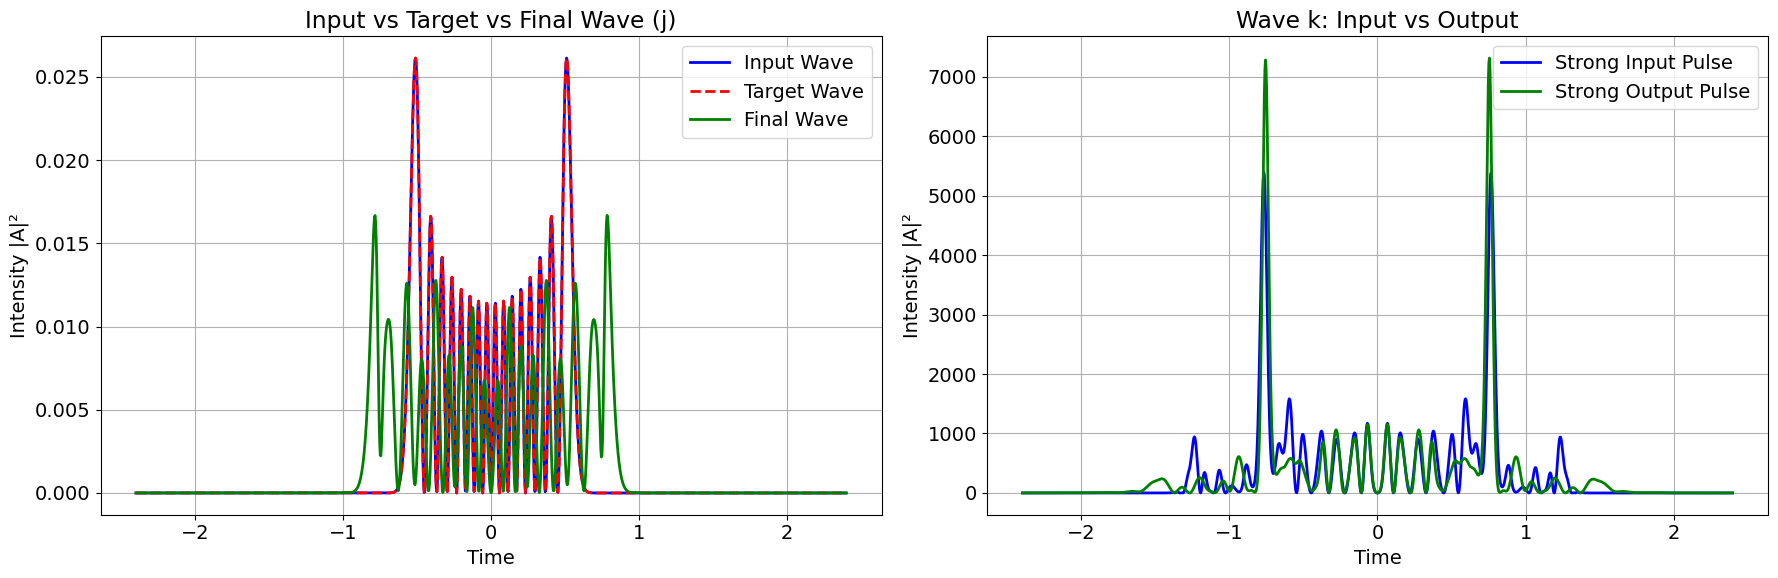

In [132]:
# Plot intensity evolution for wave j
plot_intensity_evolution(A_j_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave j")

# Plot intensity evolution for wave k
plot_intensity_evolution(A_k_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave k")

# Plot co-wave evolution
plot_cowave_evolution(
    A_j_evolution[mode_nr, :, :].detach().clone(),
    A_k_evolution[mode_nr, :, :].detach().clone(),
    t,
    Lz,
    Nz
)

"""------Target vs Final Wave------"""
# Plot target vs final wave comparison
plot_percent_comparison = 0.3  # Show central 30% of the data
center_points_comp = int(total_points * plot_percent_comparison)
start_idx_comp = (total_points - center_points_comp) // 2
end_idx_comp = start_idx_comp + center_points_comp
t_center_comp = t[start_idx_comp:end_idx_comp].cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# First subplot: Input vs Target vs Final wave (j)
ax1.plot(t_center_comp, np.abs(x[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Input Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(y[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "r--", label="Target Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Final Wave", linewidth=2)
ax1.set_xlabel("Time")
ax1.set_ylabel("Intensity |A|²")
ax1.set_title("Input vs Target vs Final Wave (j)")
ax1.legend()
ax1.grid()

# Second subplot: Wave k first and last
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, 0].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Strong Input Pulse", linewidth=2)
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Strong Output Pulse", linewidth=2)
ax2.set_xlabel("Time")
ax2.set_ylabel("Intensity |A|²")
ax2.set_title("Wave k: Input vs Output")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

### 3. Full Mode Comparison

In [133]:
def plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3):
    """Create a 4x4 grid plot showing all 16 modes: target vs final output."""
    B = y.shape[0]
    
    # Calculate time window for plotting
    total_points = len(t)
    center_points = int(total_points * plot_percent)
    start_idx = (total_points - center_points) // 2
    end_idx = start_idx + center_points
    t_plot = t[start_idx:end_idx].cpu().numpy()
    
    # Get final outputs
    final_outputs = A_j_evolution[:, :, -1].detach()
    
    # Create 4x4 subplot grid
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()
    
    for mode_idx in range(B):
        ax = axes[mode_idx]
        
        # Extract data for this mode
        target_intensity = np.abs(y[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        output_intensity = np.abs(final_outputs[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        
        # Plot target and output
        ax.plot(t_plot, target_intensity, 'r--', linewidth=2, label='Target', alpha=0.7)
        ax.plot(t_plot, output_intensity, 'b-', linewidth=2, label='Output', alpha=0.8)
        
        # Calculate and display MSE
        mse = np.mean((target_intensity - output_intensity)**2)
        ax.set_title(f'Mode {mode_idx}\nMSE: {mse:.2e}', fontsize=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Intensity |A|²', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Target vs Final Output for All 16 Modes', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()


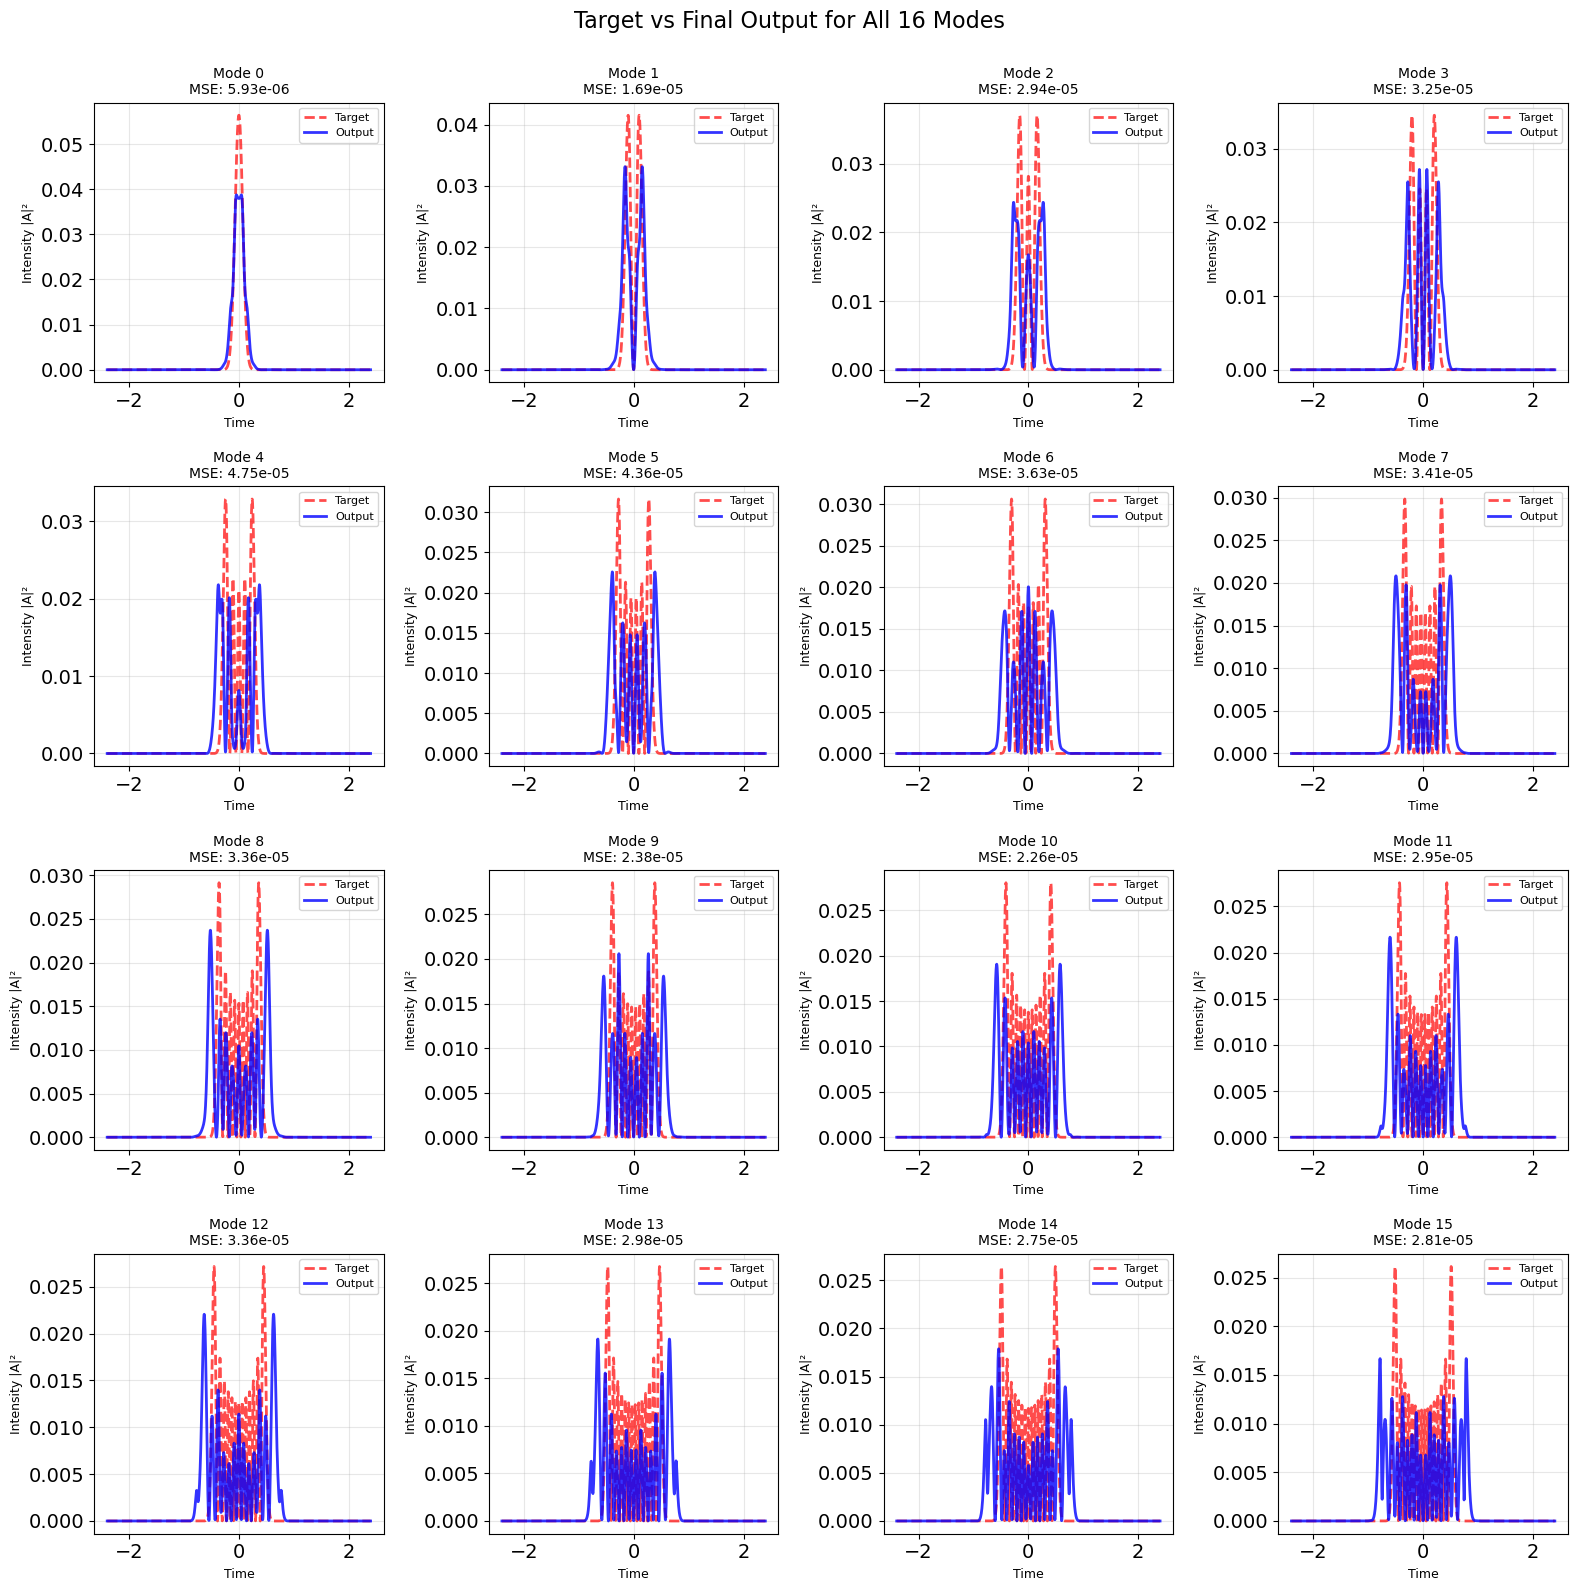


Summary Statistics:
  Mean MSE per mode: 8.90e-06
  Std MSE per mode: 2.93e-06
  Min MSE: 1.78e-06
  Max MSE: 1.42e-05


In [134]:
# Generate mode comparison plot
plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3)

# Print summary statistics
final_outputs = A_j_evolution[:, :, -1].detach()
targets = y
mse_per_mode = torch.mean((torch.abs(final_outputs)**2 - torch.abs(targets)**2)**2, dim=1)
print(f"\nSummary Statistics:")
print(f"  Mean MSE per mode: {mse_per_mode.mean().item():.2e}")
print(f"  Std MSE per mode: {mse_per_mode.std().item():.2e}")
print(f"  Min MSE: {mse_per_mode.min().item():.2e}")
print(f"  Max MSE: {mse_per_mode.max().item():.2e}")


### 4. Random Mode Combination Test

Test the identity operator with a random combination of the 16 modes.


In [135]:
# ===== PARAMETER: Set the number of modes to use =====
num_modes_to_use = 3  # Change this to use fewer modes (max = 16)
# ======================================================

In [136]:
# Generate random coefficients for the specified number of modes
np.random.seed(42)  # For reproducibility
random_coeffs = np.zeros(B)  # Start with all zeros

# Set random values only for the first num_modes_to_use modes
random_coeffs[:num_modes_to_use] = np.random.randn(num_modes_to_use)

# Normalize to L2 norm = 1
random_coeffs = random_coeffs / np.linalg.norm(random_coeffs)

# Convert to torch tensor
random_coeffs = torch.tensor(random_coeffs, dtype=torch.float32, device=device)

# Create the random combination pulse
# x contains the 16 HG modes, so we create a linear combination
random_pulse = torch.sum(random_coeffs.unsqueeze(1) * x, dim=0)

# For the batch, we'll use just this one pulse
random_pulse_batch = random_pulse.unsqueeze(0)

print(f"Number of modes used: {num_modes_to_use}/{B}")
print(f"Random coefficients (L2 norm = {torch.norm(random_coeffs).item():.6f}):")
print(f"Coefficients: {random_coeffs.cpu().numpy()}")
print(f"Non-zero coefficients: {np.count_nonzero(random_coeffs.cpu().numpy())}")
print(f"Random pulse shape: {random_pulse.shape}")
print(f"Random pulse batch shape: {random_pulse_batch.shape}")


Number of modes used: 3/16
Random coefficients (L2 norm = 1.000000):
Coefficients: [ 0.60000205 -0.1670153   0.7823704   0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]
Non-zero coefficients: 3
Random pulse shape: torch.Size([4096])
Random pulse batch shape: torch.Size([1, 4096])


In [137]:
# Run forward pass with the random pulse and trained theta
print("Running forward pass with random combination pulse...")

# Convert theta to strong pulse
Ain_k_trained = hg_to_time(theta, hg_basis)

# Run the split-step Fourier method
with torch.no_grad():
    A_j_random_evolution, A_k_random_evolution = split_step_fourier_xpm_batch(
        random_pulse_batch, Ain_k_trained, dz, Nz,
        beta2_j, beta2_k,
        gamma_j, gamma_k,
        Lt
    )

print(f"Forward pass completed!")
print(f"  A_j_random_evolution shape: {A_j_random_evolution.shape}")
print(f"  A_k_random_evolution shape: {A_k_random_evolution.shape}")


Running forward pass with random combination pulse...
Forward pass completed!
  A_j_random_evolution shape: torch.Size([1, 4096, 201])
  A_k_random_evolution shape: torch.Size([1, 4096, 201])


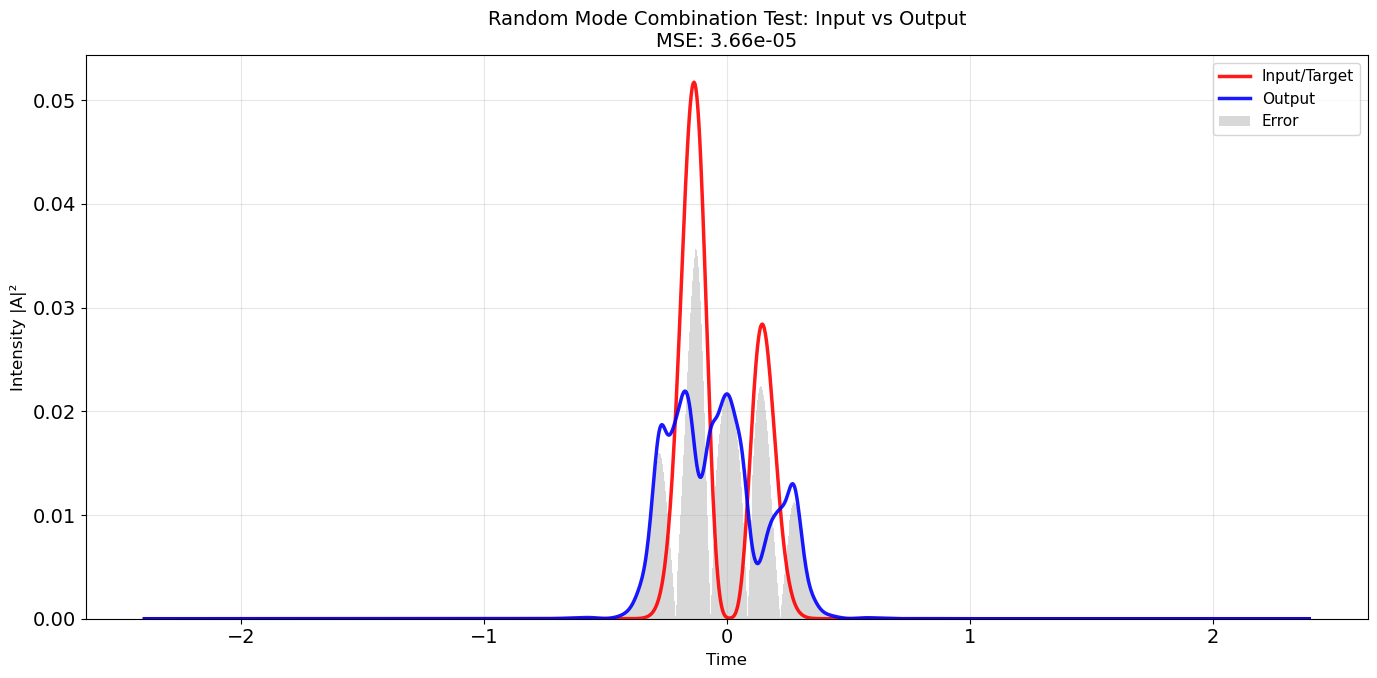


Random Combination Results:
  MSE: 3.66e-05
  Max Error: 3.57e-02
  Mean Error: 2.00e-03


In [138]:
# Prepare data for plotting
plot_percent_random = 0.3
center_points_random = int(total_points * plot_percent_random)
start_idx_random = (total_points - center_points_random) // 2
end_idx_random = start_idx_random + center_points_random
t_plot_random = t[start_idx_random:end_idx_random].cpu().numpy()

# Extract input (target), output, and compute error
input_intensity = np.abs(random_pulse.detach().cpu().numpy())[start_idx_random:end_idx_random]**2
output_intensity = np.abs(A_j_random_evolution[0, :, -1].detach().cpu().numpy())[start_idx_random:end_idx_random]**2
error = np.abs(input_intensity - output_intensity)

# Calculate MSE for this random combination
mse_random = np.mean((input_intensity - output_intensity)**2)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot input/target and output
ax.plot(t_plot_random, input_intensity, 'r-', linewidth=2.5, label='Input/Target', alpha=0.9, zorder=3)
ax.plot(t_plot_random, output_intensity, 'b-', linewidth=2.5, label='Output', alpha=0.9, zorder=3)

# Plot error as translucent bar plot
ax.bar(t_plot_random, error, width=(t_plot_random[1]-t_plot_random[0]), 
       color='gray', alpha=0.3, label='Error', zorder=1)

# Add labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Intensity |A|²', fontsize=12)
ax.set_title(f'Random Mode Combination Test: Input vs Output\nMSE: {mse_random:.2e}', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

print(f"\nRandom Combination Results:")
print(f"  MSE: {mse_random:.2e}")
print(f"  Max Error: {error.max():.2e}")
print(f"  Mean Error: {error.mean():.2e}")


### 5. HG Coefficients Comparison for Specific Mode


In [141]:
# ===== PARAMETER: Set the mode number to analyze =====
mode_nr_coeffs = 7  # Change this to analyze different modes (0 to 15)
# ======================================================


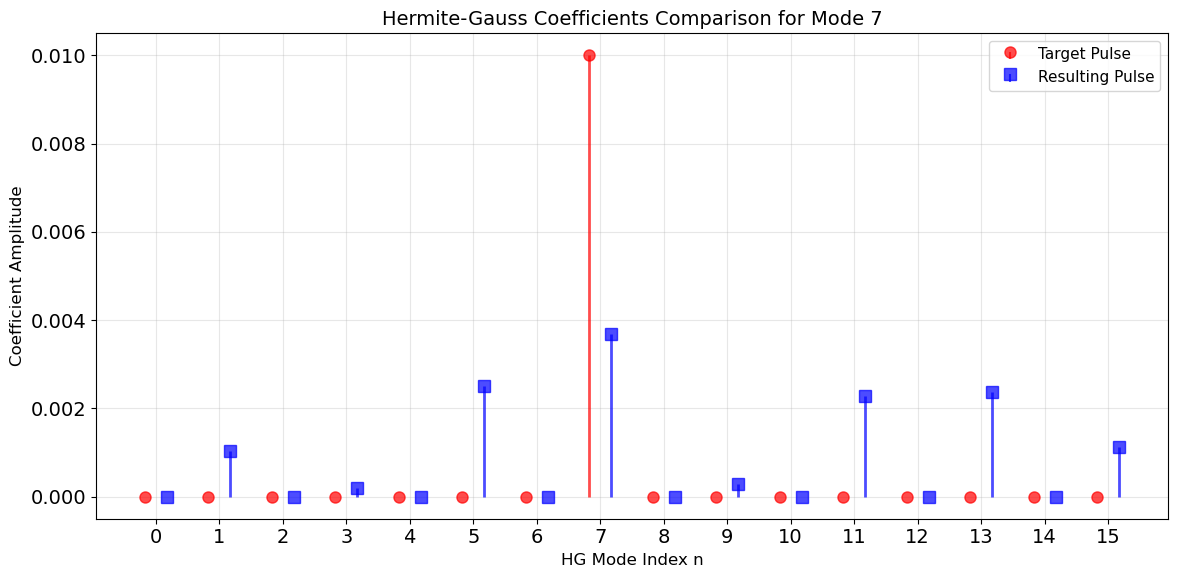


HG Coefficients Analysis for Mode 7:
  MSE between target and resulting coefficients: 3.72e-06
  Max difference: 6.32e-03
  Target coefficients (first 5): [4.0017767e-11 2.3828761e-10 1.4551915e-11 5.6752469e-10 7.2759576e-12]
  Resulting coefficients (first 5): [3.0286174e-09 1.0377031e-03 1.6450940e-08 2.0168154e-04 9.3732524e-09]


In [142]:
# Extract target and resulting pulse for the specified mode
target_pulse = y[mode_nr_coeffs]
resulting_pulse = A_j_evolution[mode_nr_coeffs, :, -1]

# Compute HG coefficients for both pulses
# Use the same HG basis (x) that was used in training
hg_basis_for_decomp = x  # This is the batch of 16 HG modes

# Compute coefficients by projecting onto the HG basis
# Using inner product (integration) in time domain
dt_val = dt  # Time step

# Compute coefficients using inner product
target_coeffs = torch.zeros(B, device=device)
resulting_coeffs = torch.zeros(B, device=device)

for i in range(B):
    # Inner product: <f, g> = integral(f * conj(g) * dt)
    target_coeffs[i] = torch.sum(target_pulse * torch.conj(hg_basis_for_decomp[i])) * dt_val
    resulting_coeffs[i] = torch.sum(resulting_pulse * torch.conj(hg_basis_for_decomp[i])) * dt_val

# Convert to numpy for plotting
target_coeffs_np = torch.abs(target_coeffs).cpu().numpy()
resulting_coeffs_np = torch.abs(resulting_coeffs).cpu().numpy()
mode_indices = np.arange(B)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot coefficients as stem plots with offset for visibility
width = 0.35
x_target = mode_indices - width/2
x_resulting = mode_indices + width/2

markerline1, stemlines1, baseline1 = ax.stem(x_target, target_coeffs_np, basefmt=' ', 
                                              label='Target Pulse', linefmt='r-', markerfmt='ro')
markerline2, stemlines2, baseline2 = ax.stem(x_resulting, resulting_coeffs_np, basefmt=' ',
                                              label='Resulting Pulse', linefmt='b-', markerfmt='bs')

# Styling
plt.setp(stemlines1, linewidth=2, alpha=0.7)
plt.setp(markerline1, markersize=8, alpha=0.7)
plt.setp(stemlines2, linewidth=2, alpha=0.7)
plt.setp(markerline2, markersize=8, alpha=0.7)

ax.set_xlabel('HG Mode Index n', fontsize=12)
ax.set_ylabel('Coefficient Amplitude', fontsize=12)
ax.set_title(f'Hermite-Gauss Coefficients Comparison for Mode {mode_nr_coeffs}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(mode_indices)

plt.tight_layout()
plt.show()

# Print coefficient statistics
coeff_mse = np.mean((target_coeffs_np - resulting_coeffs_np)**2)
print(f"\nHG Coefficients Analysis for Mode {mode_nr_coeffs}:")
print(f"  MSE between target and resulting coefficients: {coeff_mse:.2e}")
print(f"  Max difference: {np.max(np.abs(target_coeffs_np - resulting_coeffs_np)):.2e}")
print(f"  Target coefficients (first 5): {target_coeffs_np[:5]}")
print(f"  Resulting coefficients (first 5): {resulting_coeffs_np[:5]}")
